In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv('datasets/student_scores.csv')

In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 528.0 bytes


,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [17]:
df.duplicated().sum()

0

In [18]:
df.isnull().sum()

Hours     0
Scores    0
dtype: int64

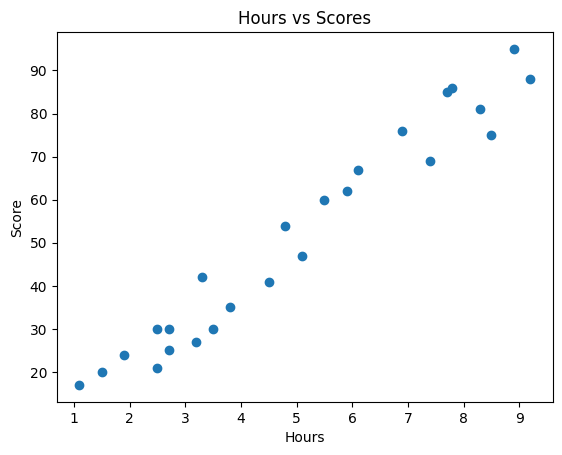

In [10]:
plt.scatter(df['Hours'],df['Scores'])
plt.xlabel('Hours')
plt.ylabel('Score')
plt.title("Hours vs Scores")
plt.show()

In [11]:
df.corr(numeric_only=True)

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


In [20]:
X = df[['Hours']]
y = df['Scores']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)


In [21]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

print("Predictions:")
print(predictions)

Coefficient: [9.68207815]
Intercept: 2.826892353899737
Predictions:
[83.18814104 27.03208774 27.03208774 69.63323162 59.95115347]


In [25]:
mae = mean_absolute_error(y_test,predictions)
mse = mean_squared_error(y_test,predictions)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mse)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3.9207511902099244
MSE : 18.943211722315272
RMSE: 4.352380006653288
R²  : 0.9678055545167994
